# Which topics are the most structurally important in the online network of information about U.S. healthcare costs and health insurance?

### Outside Sources:
I used Wikepedia pages as my nodes and their hyper links for the paths
I used ChatGPT to help troubleshoot Python code and clarify NetworkX functions. I validated the output by running the code myself, manually checking several hyperlinks, inspecting the dataset, and verifying that the NetworkX functions produced reasonable results.

### Limitations:
You only analyzed a subset of Wikipedia.
Your starting pages influence which pages appear in the network.
Wikipedia's links reflect editorial decisions.
A hyperlink does not necessarily mean a topic is medically or economically more important.
PageRank measures structural importance, not patient importance.
Wikipedia changes over time.

## Stakeholder: A patient-education nonprofit or hospital financial counseling department.
## Decision: The organization wants to create an online guide explaining healthcare costs and insurance and needs to decide which concepts should be introduced first and linked most prominently.

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from urllib.parse import urljoin, urlparse, unquote

In [2]:
pages = [
    "Health_economics",
    "Health_insurance_in_the_United_States",
    "Healthcare_in_the_United_States",
    "Medicare_(United_States)",
    "Medicaid",
    "Medical_debt",
    "Prescription_drug_prices_in_the_United_States",
    "Affordable_Care_Act"
]

print("Starting pages:", len(pages))

Starting pages: 8


In [3]:
headers = {
    "User-Agent": "INST414HealthcareNetwork/1.0 (student research project)"
}

In [4]:
url = "https://en.wikipedia.org/wiki/Health_economics"

response = requests.get(url, headers=headers)

print(response.status_code)

200


In [5]:
edges = []

bad_prefixes = (
    "File:",
    "Help:",
    "Category:",
    "Special:",
    "Talk:",
    "Wikipedia:",
    "Template:",
    "Portal:"
)

bad_pages = (
    "Main_Page",
    "Contents",
    "Current_events",
    "About_Wikipedia",
    "Contact_us"
)

for page in pages:

    url = "https://en.wikipedia.org/wiki/" + page

    response = requests.get(url, headers=headers)

    print(page, response.status_code)

    if response.status_code != 200:
        continue

    soup = BeautifulSoup(response.text, "html.parser")

    links = soup.find_all("a", href=True)

    for link in links:

        href = link["href"]

        full_url = urljoin(url, href)

        parsed = urlparse(full_url)

        # Keep only English Wikipedia pages
        if parsed.netloc != "en.wikipedia.org":
            continue

        # Keep only article-style Wikipedia links
        if not parsed.path.startswith("/wiki/"):
            continue

        target = parsed.path.replace("/wiki/", "", 1)

        target = unquote(target)

        if not target:
            continue

        if target.startswith(bad_prefixes):
            continue

        if target in bad_pages:
            continue

        if target == page:
            continue

        edges.append([page, target])

Health_economics 200
Health_insurance_in_the_United_States 200
Healthcare_in_the_United_States 200
Medicare_(United_States) 200
Medicaid 200
Medical_debt 200
Prescription_drug_prices_in_the_United_States 200
Affordable_Care_Act 200


In [6]:
print("Number of raw links:", len(edges))

edges[:10]

Number of raw links: 6923


[['Health_economics', 'Health_Economics'],
 ['Health_economics', 'Public_health'],
 ['Health_economics', 'Outline_of_public_health'],
 ['Health_economics', 'Community_health'],
 ['Health_economics', 'Dental_public_health'],
 ['Health_economics', 'Environmental_health'],
 ['Health_economics', 'Epidemiology'],
 ['Health_economics', 'Health_education'],
 ['Health_economics', 'Health_promotion'],
 ['Health_economics', 'Health_policy']]

In [7]:
raw_df = pd.DataFrame(
    edges,
    columns=["source", "target"]
)

raw_df = raw_df.drop_duplicates()

print("Raw dataframe shape:", raw_df.shape)

raw_df.head(20)

Raw dataframe shape: (4569, 2)


,source,target
0,Health_economics,Health_Economics
1,Health_economics,Public_health
2,Health_economics,Outline_of_public_health
3,Health_economics,Community_health
4,Health_economics,Dental_public_health
5,Health_economics,Environmental_health
6,Health_economics,Epidemiology
7,Health_economics,Health_education
8,Health_economics,Health_promotion
9,Health_economics,Health_policy


In [8]:
raw_df.to_csv(
    "data/raw_healthcare_links.csv",
    index=False
)

In [9]:
keywords = [
    "health",
    "healthcare",
    "health_care",
    "insurance",
    "medicare",
    "medicaid",
    "medical",
    "hospital",
    "patient",
    "prescription",
    "drug",
    "pharmaceutical",
    "cost",
    "price",
    "spending",
    "debt",
    "coverage",
    "econom",
    "affordable_care"
]

In [10]:
def is_relevant(title):

    title = title.lower()

    return any(
        word in title
        for word in keywords
    )

In [11]:
relevant_counts = (
    raw_df[
        raw_df["target"].apply(is_relevant)
    ]["target"]
    .value_counts()
)

relevant_counts.head(50)

Health_insurance                                                      6
Health_insurance_marketplace                                          6
Medicare_for_All_Act                                                  6
Patient_Protection_and_Affordable_Care_Act                            6
United_States_Department_of_Health_and_Human_Services                 5
Children's_Health_Insurance_Program                                   5
Federal_Employees_Health_Benefits_Program                             5
Medicaid                                                              5
Medicare_(United_States)                                              5
Centers_for_Medicare_and_Medicaid_Services                            5
Veterans_Health_Administration                                        5
Medicare_Prescription_Drug,_Improvement,_and_Modernization_Act        5
Flexible_spending_account                                             5
Affordable_Care_Act                                             

In [12]:
selected_pages = [
    "Health_economics",
    "Health_insurance",
    "Health_insurance_in_the_United_States",
    "Health_insurance_marketplace",
    "Healthcare_in_the_United_States",
    "Health_care_prices_in_the_United_States",
    "Medical_debt",
    "Prescription_drug_prices_in_the_United_States",

    "Medicare_(United_States)",
    "Medicaid",
    "Children's_Health_Insurance_Program",
    "Medicare_Advantage",
    "Medicare_Part_D",
    "Medicare_for_All_Act",
    "Centers_for_Medicare_and_Medicaid_Services",

    "Affordable_Care_Act",
    "Healthcare_reform_in_the_United_States",
    "Health_policy",
    "Universal_health_care",
    "Social_insurance",

    "Health_savings_account",
    "Flexible_spending_account",
    "Health_reimbursement_account",
    "High-deductible_health_plan",
    "Medical_underwriting",
    "Health_maintenance_organization",
    "Consumer-driven_healthcare",

    "United_States_Department_of_Health_and_Human_Services",
    "Veterans_Health_Administration",
    "Indian_Health_Service",
    "Federal_Employees_Health_Benefits_Program"
]

print("Number of selected pages:", len(selected_pages))

Number of selected pages: 31


In [13]:
final_edges = []

selected_set = set(selected_pages)

for page in selected_pages:

    url = "https://en.wikipedia.org/wiki/" + page

    response = requests.get(url, headers=headers)

    print(page, response.status_code)

    if response.status_code != 200:
        continue

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    links = soup.find_all(
        "a",
        href=True
    )

    for link in links:

        href = link["href"]

        full_url = urljoin(
            url,
            href
        )

        parsed = urlparse(
            full_url
        )

        if parsed.netloc != "en.wikipedia.org":
            continue

        if not parsed.path.startswith("/wiki/"):
            continue

        target = parsed.path.replace(
            "/wiki/",
            "",
            1
        )

        target = unquote(target)

        # Only keep links between the 31 selected pages
        if target in selected_set and target != page:

            final_edges.append(
                [page, target]
            )

Health_economics 200
Health_insurance 200
Health_insurance_in_the_United_States 200
Health_insurance_marketplace 200
Healthcare_in_the_United_States 200
Health_care_prices_in_the_United_States 200
Medical_debt 200
Prescription_drug_prices_in_the_United_States 200
Medicare_(United_States) 200
Medicaid 200
Children's_Health_Insurance_Program 200
Medicare_Advantage 200
Medicare_Part_D 200
Medicare_for_All_Act 200
Centers_for_Medicare_and_Medicaid_Services 200
Affordable_Care_Act 200
Healthcare_reform_in_the_United_States 200
Health_policy 200
Universal_health_care 200
Social_insurance 200
Health_savings_account 200
Flexible_spending_account 200
Health_reimbursement_account 200
High-deductible_health_plan 200
Medical_underwriting 200
Health_maintenance_organization 200
Consumer-driven_healthcare 200
United_States_Department_of_Health_and_Human_Services 200
Veterans_Health_Administration 200
Indian_Health_Service 200
Federal_Employees_Health_Benefits_Program 200


In [14]:
final_df = pd.DataFrame(
    final_edges,
    columns=["source", "target"]
)

final_df = final_df.drop_duplicates()

print("Final dataframe shape:", final_df.shape)

final_df.head(20)

Final dataframe shape: (376, 2)


,source,target
0,Health_economics,Health_policy
1,Health_economics,Universal_health_care
2,Health_economics,Health_insurance_in_the_United_States
3,Health_economics,Health_insurance
5,Health_economics,Health_insurance_marketplace
7,Health_economics,Medical_debt
9,Health_economics,Healthcare_in_the_United_States
11,Health_insurance,Health_policy
12,Health_insurance,Universal_health_care
13,Health_insurance,Health_insurance_in_the_United_States


In [15]:
final_df.to_csv(
    "data/healthcare_links.csv",
    index=False
)

In [16]:
G = nx.from_pandas_edgelist(
    final_df,
    source="source",
    target="target",
    create_using=nx.DiGraph()
)

# Include selected pages even if one happens to have no links
G.add_nodes_from(selected_pages)

print(
    "Nodes:",
    G.number_of_nodes()
)

print(
    "Edges:",
    G.number_of_edges()
)

Nodes: 31
Edges: 376


In [17]:
pagerank = nx.pagerank(G)

results = pd.DataFrame(
    pagerank.items(),
    columns=["page", "pagerank"]
)

results = results.sort_values(
    "pagerank",
    ascending=False
).reset_index(drop=True)

results.head(10)

,page,pagerank
0,Medicaid,0.063977
1,Health_insurance,0.063357
2,Medicare_(United_States),0.062888
3,Health_insurance_in_the_United_States,0.055323
4,Affordable_Care_Act,0.052222
5,Indian_Health_Service,0.044791
6,Health_maintenance_organization,0.041049
7,Health_insurance_marketplace,0.040879
8,United_States_Department_of_Health_and_Human_S...,0.040344
9,Healthcare_reform_in_the_United_States,0.032535


In [18]:
results.head(3)

,page,pagerank
0,Medicaid,0.063977
1,Health_insurance,0.063357
2,Medicare_(United_States),0.062888


In [19]:
betweenness = nx.betweenness_centrality(G)

betweenness_results = pd.DataFrame(
    betweenness.items(),
    columns=["page", "betweenness"]
)

betweenness_results = betweenness_results.sort_values(
    "betweenness",
    ascending=False
).reset_index(drop=True)

betweenness_results.head(10)

,page,betweenness
0,Medicare_(United_States),0.109025
1,Health_insurance_in_the_United_States,0.088663
2,Medicaid,0.078888
3,Affordable_Care_Act,0.071398
4,Health_insurance,0.063531
5,Healthcare_in_the_United_States,0.051532
6,Healthcare_reform_in_the_United_States,0.030910
7,Health_maintenance_organization,0.025488
8,Children's_Health_Insurance_Program,0.013845
9,Health_insurance_marketplace,0.011116


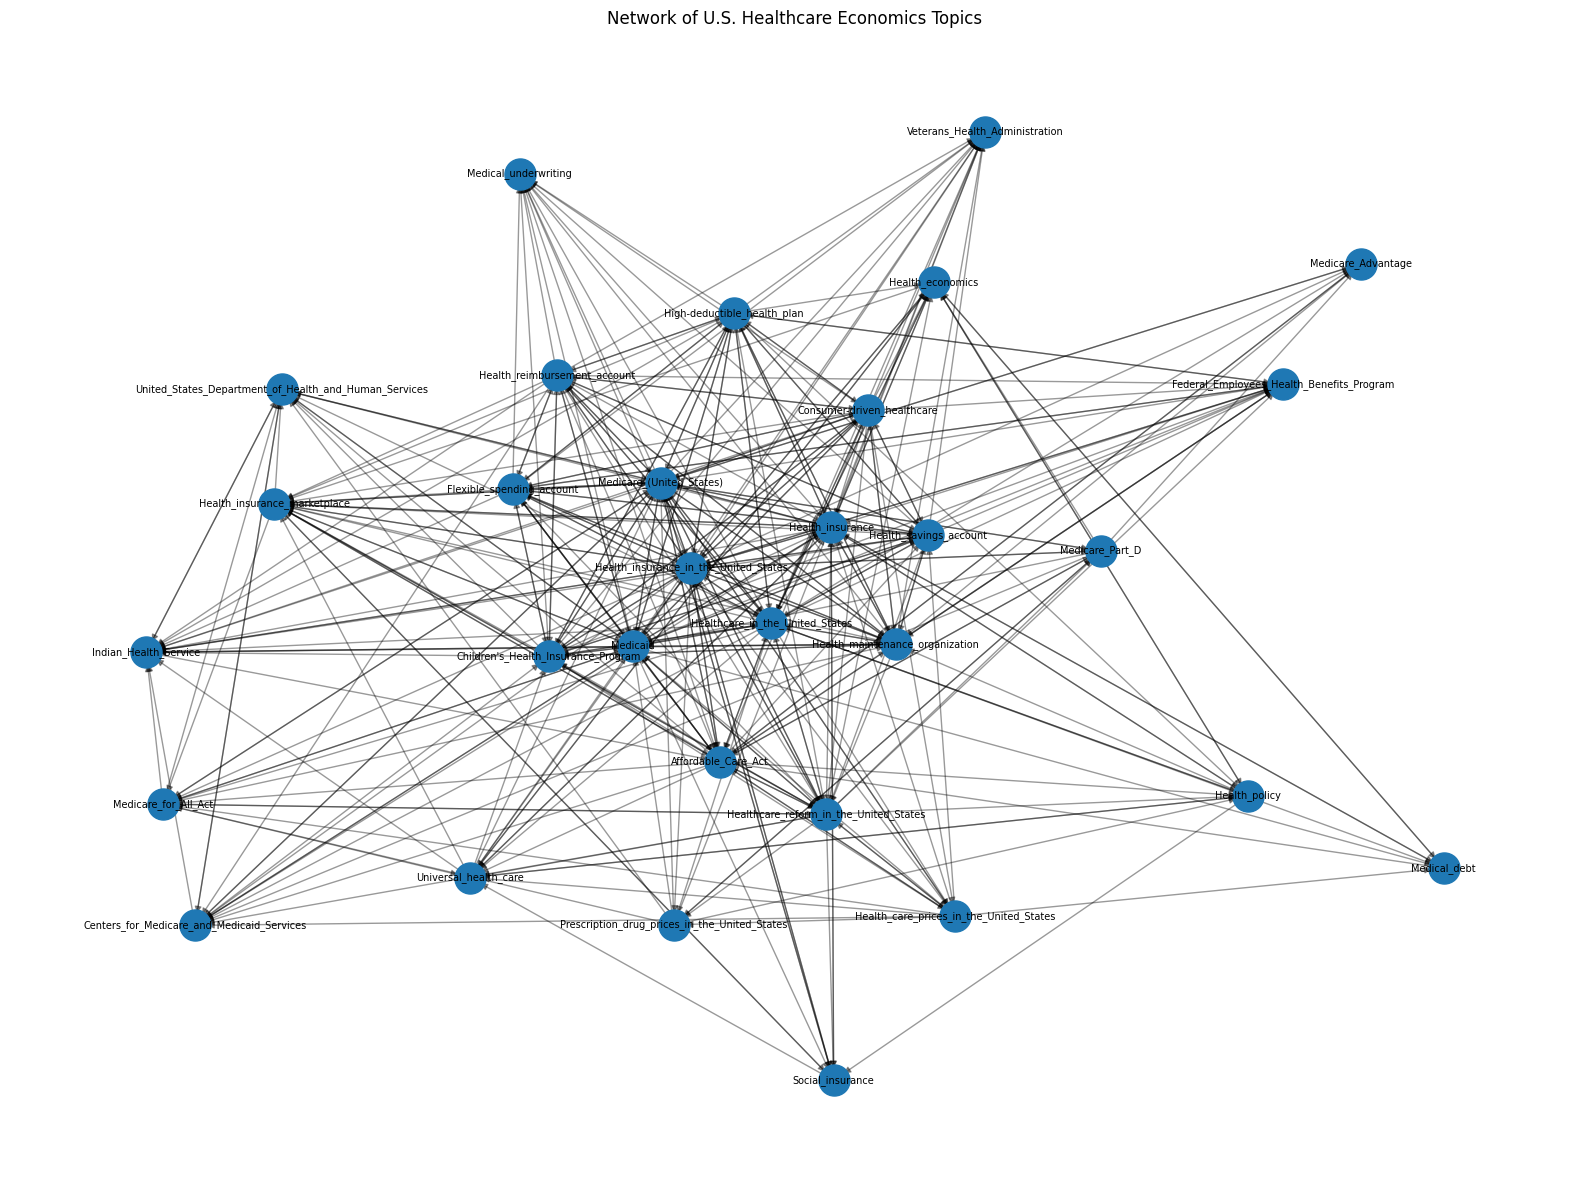

In [20]:
plt.figure(figsize=(16, 12))

pos = nx.spring_layout(
    G,
    seed=42,
    k=1.5
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=500
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    alpha=0.4
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=7
)

plt.title(
    "Network of U.S. Healthcare Economics Topics"
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    "figures/network.png",
    bbox_inches="tight"
)

plt.show()

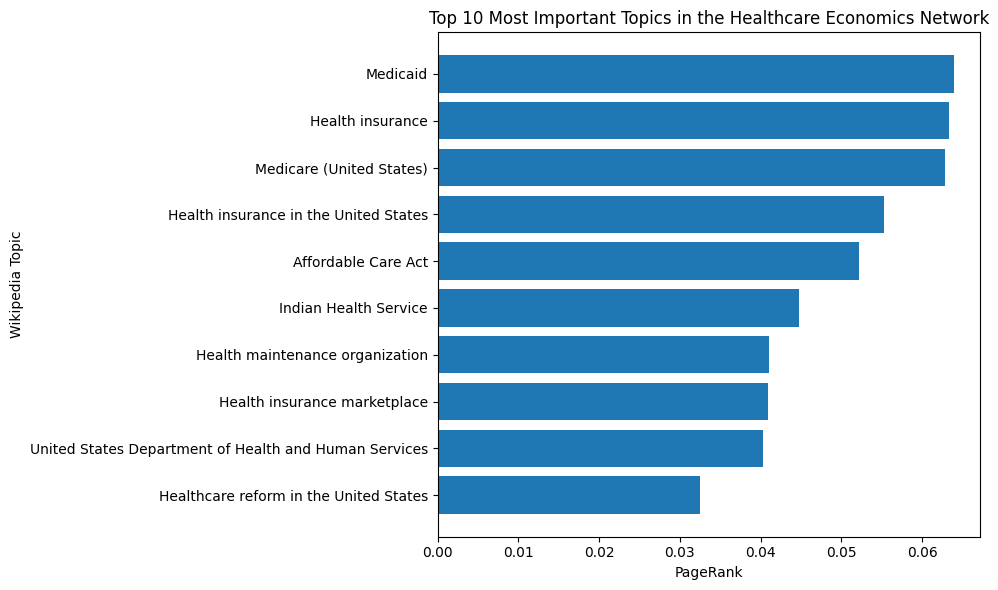

In [21]:
top10 = results.head(10).copy()

top10["page"] = (
    top10["page"]
    .str.replace("_", " ")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["page"],
    top10["pagerank"]
)

plt.xlabel("PageRank")

plt.ylabel(
    "Wikipedia Topic"
)

plt.title(
    "Top 10 Most Important Topics in the Healthcare Economics Network"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "figures/top10_pagerank.png",
    bbox_inches="tight"
)

plt.show()

In [22]:
results.to_csv(
    "data/pagerank_results.csv",
    index=False
)

In [23]:
print(
    "Final number of nodes:",
    G.number_of_nodes()
)

print(
    "Final number of edges:",
    G.number_of_edges()
)

print(
    "\nTop 10 PageRank results:"
)

print(
    results.head(10)
)

Final number of nodes: 31
Final number of edges: 376

Top 10 PageRank results:
                                                page  pagerank
0                                           Medicaid  0.063977
1                                   Health_insurance  0.063357
2                           Medicare_(United_States)  0.062888
3              Health_insurance_in_the_United_States  0.055323
4                                Affordable_Care_Act  0.052222
5                              Indian_Health_Service  0.044791
6                    Health_maintenance_organization  0.041049
7                       Health_insurance_marketplace  0.040879
8  United_States_Department_of_Health_and_Human_S...  0.040344
9             Healthcare_reform_in_the_United_States  0.032535


In [24]:
unexpected_nodes = [
    node
    for node in G.nodes()
    if node not in selected_set
]

print(
    "Unexpected nodes:",
    unexpected_nodes
)

Unexpected nodes: []
